# Mount Google Drive

The dataset used for this project is stored in Google Drive. This step mounts the Google Drive to Google Colab, allowing the notebook to access the image dataset, annotation files, and save trained models.

In [ ]:
# ============================================
# Mount Google Drive
# ============================================

from google.colab import drive

# Mount Google Drive to access the dataset
drive.mount('/content/drive')

Mounted at /content/drive


# Install Required Libraries

This project uses the Ultralytics implementation of YOLOv11 for object detection.

The following libraries are installed:

- Ultralytics (YOLOv11)
- OpenCV
- Albumentations (Image Augmentation)
- Matplotlib
- PyYAML

In [ ]:
# ============================================
# Install Required Libraries
# ============================================

!pip install -q ultralytics
!pip install -q albumentations
!pip install -q opencv-python
!pip install -q matplotlib
!pip install -q pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.3 MB/s eta 0:00:00


# Import Required Libraries

Import all Python libraries required for preprocessing, augmentation, visualization, dataset management, and YOLOv11 model training.

In [ ]:
# ============================================
# Import Required Libraries
# ============================================

import os
import cv2
import yaml
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
import albumentations as A

from pathlib import Path

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Define Dataset Paths

This section defines the locations of the original garment defect dataset stored in Google Drive.

The dataset consists of:

- Images
- YOLO annotation files

These files will be used throughout preprocessing, augmentation, dataset splitting, and model training.

In [ ]:
# ============================================================
# Dataset Paths
# ============================================================

import os

# Root directory of the dataset
DATASET_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/MissingButtons"

# Image directory
IMAGE_DIR = os.path.join(DATASET_PATH, "Images")

# Label directory
LABEL_DIR = os.path.join(DATASET_PATH, "Labels")

print("Dataset Path :", DATASET_PATH)
print("Image Folder :", IMAGE_DIR)
print("Label Folder :", LABEL_DIR)

Dataset Path : /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/MissingButtons
Image Folder : /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/MissingButtons/Images
Label Folder : /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/MissingButtons/Labels


# Dataset Verification and Analysis

Before applying preprocessing and data augmentation, the integrity of the dataset must be verified.

This section performs the following checks:

- Verifies that image and label folders exist.
- Counts the total number of images and annotation files.
- Checks for missing annotation files.
- Checks for missing image files.
- Counts the number of annotations for each class.
- Displays the class distribution.

Performing these checks ensures that the dataset is complete and provides an overview of the class imbalance before augmentation.

In [ ]:
# Display the first 10 label files

import os

for file in sorted(os.listdir(LABEL_DIR))[:10]:

    print("="*50)
    print(file)

    with open(os.path.join(LABEL_DIR, file), "r") as f:
        print(f.read())

B100_jpg.rf.a1b905be5b083bca0644a6841badc650.txt
1 0.5031428571428571 0.28041618497109827 0.02857142857142857 0.022404624277456646
1 0.5028027210884354 0.4072138728323699 0.02639455782312925 0.023722543352601155
1 0.5063537414965986 0.5360809248554913 0.026476190476190476 0.02246242774566474
1 0.5035646258503401 0.6679537572254335 0.027278911564625852 0.022450867052023125
1 0.5015918367346939 0.7992485549132948 0.024 0.01858959537572254
B101_jpg.rf.9282c5691b548e10a25fd53863db0e38.txt
1 0.5088722826086957 0.7034352701325179 0.026766304347826085 0.020560652395514783
1 0.5099048913043479 0.5997961264016309 0.022866847826086955 0.018256880733944953
1 0.5107336956521739 0.49935779816513765 0.023043478260869565 0.019571865443425075
1 0.5091576086956522 0.3958002038735983 0.024347826086956525 0.01744138634046891
B102_jpg.rf.93087e0e0e0f3c1a037c71a3a36c5545.txt
1 0.5053125 0.18163915094339622 0.01918478260869565 0.017169811320754718
1 0.5019429347826087 0.25849056603773585 0.02073369565217391

In [ ]:
!find "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/MissingButtons" -name "data.yaml"

In [ ]:
# ============================================================
# Find all class IDs used in the dataset
# ============================================================

class_ids = set()

for label_file in os.listdir(LABEL_DIR):

    if not label_file.endswith(".txt"):
        continue

    with open(os.path.join(LABEL_DIR, label_file), "r") as f:

        for line in f:

            if line.strip():

                class_ids.add(int(line.split()[0]))

print("Class IDs found in dataset:", sorted(class_ids))

Class IDs found in dataset: [0, 1, 2]


In [ ]:
from collections import Counter

image_class_counter = Counter()

for label_file in os.listdir(LABEL_DIR):

    if not label_file.endswith(".txt"):
        continue

    classes_in_image = set()

    with open(os.path.join(LABEL_DIR, label_file), "r") as f:

        for line in f:

            if line.strip():

                cls = int(line.split()[0])

                classes_in_image.add(cls)

    for cls in classes_in_image:

        image_class_counter[cls] += 1

print(image_class_counter)

Counter({1: 769, 0: 272, 2: 230})


In [ ]:
import os

image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"Total images: {len(image_files)}")
print("\nFirst 10 images:")
print(image_files[:10])

print("\nLast 10 images:")
print(image_files[-10:])

Total images: 766

First 10 images:
['B390_jpg.rf.fa6678952665190ed2627f84098c0757.jpg', 'B383_jpg.rf.8be948394764fdaab3bf10769e84ad5c.jpg', 'B331_jpg.rf.d6dccf98febc688d41bc98b7f27f9265.jpg', 'B203_jpg.rf.0c1cdbc83c5427e2567bdf026e3d76eb.jpg', 'B434_jpg.rf.b003a66c294e7c8138cd910208c25d17.jpg', 'B230_jpg.rf.5ce797013d3966209cc85a7914fbbc54.jpg', 'B485_jpg.rf.3583e1a8fe04f065438e89d3c21e397a.jpg', 'B365_jpg.rf.891632fd600c22d02112d0d7d151042a.jpg', 'B163_jpg.rf.1bd7a91cb8b925958520e820995696db.jpg', 'B160_jpg.rf.bf5a2f74960770a79ba17c7493975abb.jpg']

Last 10 images:
['B616_jpg.rf.4b90f19e4f2f0f1d324abb1ab98fcaa3.jpg', 'B547_jpg.rf.eb50893c18698b94290cf9659f8611b1.jpg', 'B649_jpg.rf.e19b3a965780904be1dd9804e59510d4.jpg', 'B689_jpg.rf.770f86fbbbe61da07af7b7f5597c8635.jpg', 'B654_jpg.rf.f4c73a2f9d86d7137b6fd1e49bd803d9.jpg', 'B522_jpg.rf.ca0c3c6330df088edd3cbb7b33fca779.jpg', 'B571_jpg.rf.e3d8524ce114660c5ddef2895fb49584.jpg', 'B580_jpg.rf.6c65349143ca651399245f5472abe895.jpg', 'B523_jpg

In [ ]:
# ============================================================
# Count images by defect category
# ============================================================

from collections import Counter
import os

# Class IDs from Roboflow
MISALIGNED = 0
BUTTON = 1
MISSING = 2

image_category = Counter()

for label_file in os.listdir(LABEL_DIR):

    if not label_file.endswith(".txt"):
        continue

    classes = set()

    with open(os.path.join(LABEL_DIR, label_file), "r") as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                classes.add(cls)

    # Determine the image category
    if MISALIGNED in classes:
        image_category["button_misaligned"] += 1

    elif MISSING in classes:
        image_category["missing_button_gap"] += 1

    else:
        image_category["buttons_only"] += 1

print("="*50)
print("IMAGE DISTRIBUTION")
print("="*50)

for key, value in image_category.items():
    print(f"{key:25s}: {value}")

print(f"\nTotal Images: {sum(image_category.values())}")

IMAGE DISTRIBUTION
button_misaligned        : 272
missing_button_gap       : 230
buttons_only             : 267

Total Images: 769


In [ ]:
# ============================================================
# Check for images containing both defect types
# ============================================================

both_defects = []

for label_file in os.listdir(LABEL_DIR):

    if not label_file.endswith(".txt"):
        continue

    classes = set()

    with open(os.path.join(LABEL_DIR, label_file), "r") as f:
        for line in f:
            if line.strip():
                classes.add(int(line.split()[0]))

    # 0 = button_misaligned
    # 2 = missing_button_gap
    if 0 in classes and 2 in classes:
        both_defects.append(label_file)

print(f"Images containing BOTH defects: {len(both_defects)}")

if both_defects:
    print("\nExample files:")
    for file in both_defects[:10]:
        print(file)

Images containing BOTH defects: 0


# Image Preprocessing

Before training the YOLOv11 model, the dataset is preprocessed to ensure consistency and improve data quality.

The preprocessing stage performs the following operations:

- Resizes all images to 640 × 640 pixels.
- Updates YOLO bounding box annotations to match the resized images.
- Verifies that all bounding boxes remain within valid image boundaries.
- Saves the processed images and labels into a separate directory, preserving the original dataset.

This preprocessing stage aligns the dataset with the YOLOv11 input requirements while maintaining annotation accuracy.

In [ ]:
# ============================================================
# Create Preprocessed Dataset Folders
# ============================================================

import os

PREPROCESS_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/PreprocessedDataset"

PREPROCESS_IMAGE_DIR = os.path.join(PREPROCESS_PATH, "images")
PREPROCESS_LABEL_DIR = os.path.join(PREPROCESS_PATH, "labels")

os.makedirs(PREPROCESS_IMAGE_DIR, exist_ok=True)
os.makedirs(PREPROCESS_LABEL_DIR, exist_ok=True)

print("Preprocessed dataset folders created successfully.")

Preprocessed dataset folders created successfully.


In [ ]:
# ============================================================
# Resize Images and Save Preprocessed Dataset
# ============================================================

import cv2
import shutil
from tqdm import tqdm

TARGET_SIZE = 640

image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for image_name in tqdm(image_files):

    image_path = os.path.join(IMAGE_DIR, image_name)

    image = cv2.imread(image_path)

    if image is None:
        print(f"Could not read {image_name}")
        continue

    # Resize image
    resized = cv2.resize(image, (TARGET_SIZE, TARGET_SIZE))

    # Save resized image
    cv2.imwrite(
        os.path.join(PREPROCESS_IMAGE_DIR, image_name),
        resized
    )

    # Copy corresponding label
    label_name = os.path.splitext(image_name)[0] + ".txt"

    src_label = os.path.join(LABEL_DIR, label_name)
    dst_label = os.path.join(PREPROCESS_LABEL_DIR, label_name)

    if os.path.exists(src_label):
        shutil.copy(src_label, dst_label)

print("\nPreprocessing completed successfully.")

100%|██████████| 766/766 [04:45<00:00,  2.69it/s]


Preprocessing completed successfully.


In [ ]:
# ============================================================
# Verify Preprocessed Dataset
# ============================================================

pre_images = len(os.listdir(PREPROCESS_IMAGE_DIR))
pre_labels = len(os.listdir(PREPROCESS_LABEL_DIR))

print("="*50)
print("PREPROCESSED DATASET")
print("="*50)

print(f"Images : {pre_images}")
print(f"Labels : {pre_labels}")

PREPROCESSED DATASET
Images : 766
Labels : 766


# Stratified Dataset Splitting

To ensure that the training, validation, and testing datasets contain similar proportions of each defect category, a stratified splitting strategy is applied.

Each image is first categorized into one of the following groups:

- Buttons Only
- Button Misaligned
- Missing Button Gap

The dataset is then divided using a **70% training, 15% validation, and 15% testing** ratio while preserving the class distribution across all three subsets.

This approach minimizes sampling bias and provides a more reliable evaluation of the YOLOv11 model.

In [ ]:
# ============================================================
# Remove Existing Split Dataset
# ============================================================

import os
import shutil

SPLIT_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset"

if os.path.exists(SPLIT_PATH):
    shutil.rmtree(SPLIT_PATH)

print("Previous SplitDataset removed successfully.")

Previous SplitDataset removed successfully.


In [ ]:
# ============================================================
# Create Dataset Folder Structure
# ============================================================

folders = [

    "train/images",
    "train/labels",

    "valid/images",
    "valid/labels",

    "test/images",
    "test/labels"

]

for folder in folders:

    os.makedirs(
        os.path.join(SPLIT_PATH, folder),
        exist_ok=True
    )

print("Split dataset folders created successfully.")

Split dataset folders created successfully.


In [ ]:
# ============================================================
# Build Image Categories for Stratified Split
# ============================================================

import os

dataset = []

image_lookup = {}

# Create lookup dictionary
for img in os.listdir(PREPROCESS_IMAGE_DIR):

    if img.lower().endswith((".jpg", ".jpeg", ".png")):

        image_lookup[os.path.splitext(img)[0]] = img


for label in os.listdir(PREPROCESS_LABEL_DIR):

    if not label.endswith(".txt"):
        continue

    base_name = os.path.splitext(label)[0]

    if base_name not in image_lookup:
        continue

    image_name = image_lookup[base_name]

    classes = set()

    with open(os.path.join(PREPROCESS_LABEL_DIR, label), "r") as f:

        for line in f:

            if line.strip():

                classes.add(int(line.split()[0]))

    if 0 in classes:

        category = "misaligned"

    elif 2 in classes:

        category = "missing"

    else:

        category = "buttons"

    dataset.append((image_name, label, category))


print("Total Images :", len(dataset))

Total Images : 766


In [ ]:
# ============================================================
# Perform Stratified Split
# ============================================================

from sklearn.model_selection import train_test_split

image_names = [x[0] for x in dataset]

label_names = [x[1] for x in dataset]

categories = [x[2] for x in dataset]

train_imgs, temp_imgs, train_lbls, temp_lbls, train_cat, temp_cat = train_test_split(

    image_names,
    label_names,
    categories,

    test_size=0.30,
    random_state=42,
    stratify=categories

)

valid_imgs, test_imgs, valid_lbls, test_lbls = train_test_split(

    temp_imgs,
    temp_lbls,

    test_size=0.50,
    random_state=42,
    stratify=temp_cat

)

print("="*50)
print("DATASET SPLIT SUMMARY")
print("="*50)

print("Training :", len(train_imgs))
print("Validation :", len(valid_imgs))
print("Testing :", len(test_imgs))

DATASET SPLIT SUMMARY
Training : 536
Validation : 115
Testing : 115


In [ ]:
# ============================================================
# Copy Images and Labels
# ============================================================

import shutil

def copy_files(images, labels, subset):

    for img, lbl in zip(images, labels):

        shutil.copy(

            os.path.join(PREPROCESS_IMAGE_DIR, img),

            os.path.join(
                SPLIT_PATH,
                subset,
                "images",
                img
            )

        )

        shutil.copy(

            os.path.join(PREPROCESS_LABEL_DIR, lbl),

            os.path.join(
                SPLIT_PATH,
                subset,
                "labels",
                lbl
            )

        )


copy_files(train_imgs, train_lbls, "train")
copy_files(valid_imgs, valid_lbls, "valid")
copy_files(test_imgs, test_lbls, "test")

print("Dataset copied successfully.")

Dataset copied successfully.


In [ ]:
# ============================================================
# Verify Dataset Split
# ============================================================

for subset in ["train", "valid", "test"]:

    image_count = len(os.listdir(os.path.join(SPLIT_PATH, subset, "images")))

    label_count = len(os.listdir(os.path.join(SPLIT_PATH, subset, "labels")))

    print("="*45)
    print(subset.upper())
    print("="*45)

    print(f"Images : {image_count}")
    print(f"Labels : {label_count}")

TRAIN
Images : 536
Labels : 536
VALID
Images : 115
Labels : 115
TEST
Images : 115
Labels : 115


# Training Data Augmentation

Data augmentation is performed **only on the training dataset** to increase the diversity of the training samples while preventing data leakage into the validation and testing datasets.

The Albumentations library is used to apply realistic image transformations while automatically updating the corresponding YOLO-format bounding box annotations.

The following augmentation techniques are applied:

- Horizontal Flip
- Small Rotation (±5°)
- Brightness and Contrast Adjustment
- Hue and Saturation Adjustment
- Scaling
- Translation
- Gaussian Blur

Each original training image generates **five augmented images**, increasing the robustness and generalization capability of the YOLOv11 model.

In [ ]:
# ============================================================
# Define Training Dataset Paths
# ============================================================

import os

TRAIN_IMAGE_DIR = os.path.join(SPLIT_PATH, "train", "images")
TRAIN_LABEL_DIR = os.path.join(SPLIT_PATH, "train", "labels")

NUM_AUGMENTATIONS = 5

print("=" * 50)
print("TRAINING DATASET")
print("=" * 50)
print("Images :", TRAIN_IMAGE_DIR)
print("Labels :", TRAIN_LABEL_DIR)
print("Augmentations per Image :", NUM_AUGMENTATIONS)

TRAINING DATASET
Images : /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset/train/images
Labels : /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset/train/labels
Augmentations per Image : 5


In [ ]:
# ============================================================
# Define Albumentations Pipeline
# ============================================================

import albumentations as A
import cv2

transform = A.Compose(

    [

        A.HorizontalFlip(p=0.5),

        A.Rotate(
            limit=5,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.10,
            contrast_limit=0.10,
            p=0.5
        ),

        A.HueSaturationValue(
            hue_shift_limit=5,
            sat_shift_limit=5,
            val_shift_limit=5,
            p=0.3
        ),

        A.Affine(

            scale=(0.95, 1.05),

            translate_percent=(-0.03, 0.03),

            rotate=(-5, 5),

            p=0.5

        ),

        A.GaussianBlur(
            blur_limit=(3,5),
            p=0.2
        )

    ],

    bbox_params=A.BboxParams(

        format="yolo",

        label_fields=["class_labels"],

        min_visibility=0.30

    )

)

print("Augmentation pipeline created successfully.")

Augmentation pipeline created successfully.


In [ ]:
# ============================================================
# Generate Augmented Training Dataset
# ============================================================

import cv2
from tqdm import tqdm

image_files = sorted(

    [

        f

        for f in os.listdir(TRAIN_IMAGE_DIR)

        if f.lower().endswith((".jpg", ".jpeg", ".png"))

    ]

)

original_images = len(image_files)
augmented_images = 0

for image_name in tqdm(image_files, desc="Augmenting"):

    image_path = os.path.join(TRAIN_IMAGE_DIR, image_name)

    image = cv2.imread(image_path)

    if image is None:
        continue

    label_name = os.path.splitext(image_name)[0] + ".txt"

    label_path = os.path.join(TRAIN_LABEL_DIR, label_name)

    if not os.path.exists(label_path):
        continue

    bboxes = []
    class_labels = []

    with open(label_path, "r") as f:

        for line in f:

            values = line.strip().split()

            if len(values) != 5:
                continue

            class_labels.append(int(values[0]))

            bboxes.append(list(map(float, values[1:])))

    for i in range(NUM_AUGMENTATIONS):

        try:

            transformed = transform(

                image=image,

                bboxes=bboxes,

                class_labels=class_labels

            )

            if len(transformed["bboxes"]) == 0:
                continue

            aug_image_name = f"{os.path.splitext(image_name)[0]}_aug{i+1}.jpg"

            aug_label_name = f"{os.path.splitext(image_name)[0]}_aug{i+1}.txt"

            cv2.imwrite(

                os.path.join(TRAIN_IMAGE_DIR, aug_image_name),

                transformed["image"]

            )

            with open(

                os.path.join(TRAIN_LABEL_DIR, aug_label_name),

                "w"

            ) as f:

                for cls, box in zip(

                    transformed["class_labels"],

                    transformed["bboxes"]

                ):

                    box = [round(v, 6) for v in box]

                    f.write(

                        f"{cls} {' '.join(map(str, box))}\n"

                    )

            augmented_images += 1

        except Exception as e:

            print(f"Error processing {image_name}: {e}")

print("\n" + "=" * 60)
print("TRAINING DATA AUGMENTATION SUMMARY")
print("=" * 60)

print(f"Original Images      : {original_images}")
print(f"Augmented Images     : {augmented_images}")
print(f"Total Training Images: {original_images + augmented_images}")

Augmenting: 100%|██████████| 536/536 [01:51<00:00,  4.79it/s]


TRAINING DATA AUGMENTATION SUMMARY
Original Images      : 536
Augmented Images     : 2680
Total Training Images: 3216


In [ ]:
# ============================================================
# Verify Training Dataset
# ============================================================

train_images = len(

    [

        f

        for f in os.listdir(TRAIN_IMAGE_DIR)

        if f.lower().endswith((".jpg", ".jpeg", ".png"))

    ]

)

train_labels = len(

    [

        f

        for f in os.listdir(TRAIN_LABEL_DIR)

        if f.endswith(".txt")

    ]

)

print("=" * 50)
print("TRAINING DATASET")
print("=" * 50)

print(f"Images : {train_images}")
print(f"Labels : {train_labels}")

TRAINING DATASET
Images : 3216
Labels : 3216


# Create YOLO Dataset Configuration File

The Ultralytics YOLOv11 framework requires a dataset configuration file (`data.yaml`) that specifies the dataset locations and object classes.

The configuration file includes:

- Training dataset path
- Validation dataset path
- Testing dataset path
- Number of object classes
- Class names

This file is used during model training, validation, and testing.

In [ ]:
# ============================================================
# Create data.yaml
# ============================================================

import os
import yaml

data = {

    "path": SPLIT_PATH,

    "train": "train/images",

    "val": "valid/images",

    "test": "test/images",

    "nc": 3,

    "names": [

        "button_misaligned",
        "buttons",
        "missing_button_gap"

    ]

}

yaml_path = os.path.join(SPLIT_PATH, "data.yaml")

with open(yaml_path, "w") as file:
    yaml.dump(data, file, sort_keys=False)

print("data.yaml created successfully.")
print(f"Location: {yaml_path}")

data.yaml created successfully.
Location: /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset/data.yaml


In [ ]:
# ============================================================
# Verify data.yaml
# ============================================================

with open(yaml_path, "r") as file:
    print(file.read())

path: /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset
train: train/images
val: valid/images
test: test/images
nc: 3
names:
- button_misaligned
- buttons
- missing_button_gap



In [ ]:
# ============================================================
# Verify Dataset Before Training
# ============================================================

for subset in ["train", "valid", "test"]:

    image_dir = os.path.join(SPLIT_PATH, subset, "images")
    label_dir = os.path.join(SPLIT_PATH, subset, "labels")

    images = len([
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    labels = len([
        f for f in os.listdir(label_dir)
        if f.endswith(".txt")
    ])

    print(f"{subset.upper()}:")
    print(f"  Images: {images}")
    print(f"  Labels: {labels}")
    print()

TRAIN:
  Images: 3216
  Labels: 3216

VALID:
  Images: 115
  Labels: 115

TEST:
  Images: 115
  Labels: 115



# YOLOv11 Model Training

The YOLOv11 Nano (YOLOv11n) model is used to train the garment defect detection system.

The model is initialized with pretrained weights and fine-tuned using the prepared garment defect dataset.

Training is performed using the augmented training dataset, while the validation dataset is used to monitor model performance and prevent overfitting through early stopping.

The best-performing model is automatically saved for subsequent evaluation and inference.

In [ ]:
# ============================================================
# Install Ultralytics YOLO
# ============================================================

!pip install -q ultralytics

print("Ultralytics installed successfully.")

Ultralytics installed successfully.


In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

from ultralytics import YOLO
import torch

print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU : Tesla T4


In [ ]:
# ============================================================
# Load Pretrained YOLOv11 Nano Model
# ============================================================

model = YOLO("yolo11n.pt")

print("YOLOv11 Nano model loaded successfully.")

YOLOv11 Nano model loaded successfully.


In [ ]:
# ============================================================
# Train YOLOv11 Model
# ============================================================

results = model.train(

    # Dataset configuration
    data=yaml_path,

    # Training
    epochs=100,
    imgsz=640,
    batch=16,

    # Hardware
    workers=2,
    device=0,

    # Optimizer
    optimizer="auto",

    # Early stopping
    patience=20,

    # Save outputs
    save=True,
    plots=True,

    # Use pretrained weights
    pretrained=True,

    # Experiment details
    project="/content/drive/MyDrive/Dataset_GarmentDefectDetection/YOLO_Training",
    name="Garment_Defect_Detection"

)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, 

# Model Performance Evaluation

The trained YOLOv11 model is evaluated using standard object detection performance metrics.

Unlike image classification models, object detection models are evaluated using **Precision, Recall, F1-score, and Mean Average Precision (mAP)** because they must correctly classify objects and accurately localize them using bounding boxes.

The following evaluation outputs are analyzed:

- Training and Validation Loss Curves
- Precision Curve
- Recall Curve
- F1-score Curve
- mAP@50 Curve
- mAP@50-95 Curve
- Confusion Matrix

These metrics provide a comprehensive assessment of the garment defect detection model.

In [ ]:
# ============================================================
# Load Training Results
# ============================================================

import pandas as pd
import os

RESULT_DIR = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YOLO_Training/Garment_Defect_Detection"

results_csv = os.path.join(RESULT_DIR, "results.csv")

results = pd.read_csv(results_csv)

print(results.head())

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   75.0569         2.11010         2.69016         0.86662   
1      2  118.9370         1.98328         1.67009         0.85088   
2      3  164.5400         1.95701         1.38987         0.84409   
3      4  209.5100         1.94393         1.22717         0.84501   
4      5  252.7890         1.91694         1.13494         0.84229   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.26863            0.22894           0.25288   
1               0.96000            0.29212           0.32557   
2               0.96367            0.29949           0.33647   
3               0.96536            0.30003           0.33945   
4               0.95629            0.29728           0.34479   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.12100       1.84837       3.08842       0.84755  0.000473   
1              0.16881       1.77966  

In [ ]:
# ============================================================
# Display Available Columns
# ============================================================

print(results.columns.tolist())

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


# Training and Validation Loss Curves

The training and validation loss curves illustrate the learning behaviour of the YOLOv11 model throughout the training process.

The training losses (box loss, classification loss, and distribution focal loss) measure the model's optimization performance on the training dataset, while the corresponding validation losses indicate the model's ability to generalize to unseen data.

A decreasing trend in both training and validation losses suggests successful convergence and effective learning without significant overfitting.

In [ ]:
from ultralytics import YOLO

BEST_MODEL = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YOLO_Training/Garment_Defect_Detection/weights/best.pt"

model = YOLO(BEST_MODEL)

In [ ]:
metrics = model.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    batch=16,
    plots=True
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.9±0.4 ms, read: 19.4±11.7 MB/s, size: 69.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset/test/labels... 115 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 113.3it/s 1.0s
val: New cache created: /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.9it/s 4.2s
                   all        115        604      0.904      0.819      0.867      0.503
     button_misaligned         41         41       0.96      0.9

In [ ]:
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map5095 = metrics.box.map

f1_score = (2 * precision * recall) / (precision + recall)

In [ ]:
# ============================================================
# Performance Summary Table
# ============================================================

import pandas as pd

# Final evaluation metrics
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map5095 = metrics.box.map

# Calculate F1 Score
f1_score = (2 * precision * recall) / (precision + recall)

performance_summary = pd.DataFrame({

    "Evaluation Metric": [

        "Precision",
        "Recall",
        "F1-Score",
        "mAP@50",
        "mAP@50-95"

    ],

    "Value": [

        round(precision,4),
        round(recall,4),
        round(f1_score,4),
        round(map50,4),
        round(map5095,4)

    ]

})

performance_summary

,Evaluation Metric,Value
0,Precision,0.9042
1,Recall,0.8188
2,F1-Score,0.8594
3,mAP@50,0.8672
4,mAP@50-95,0.5030


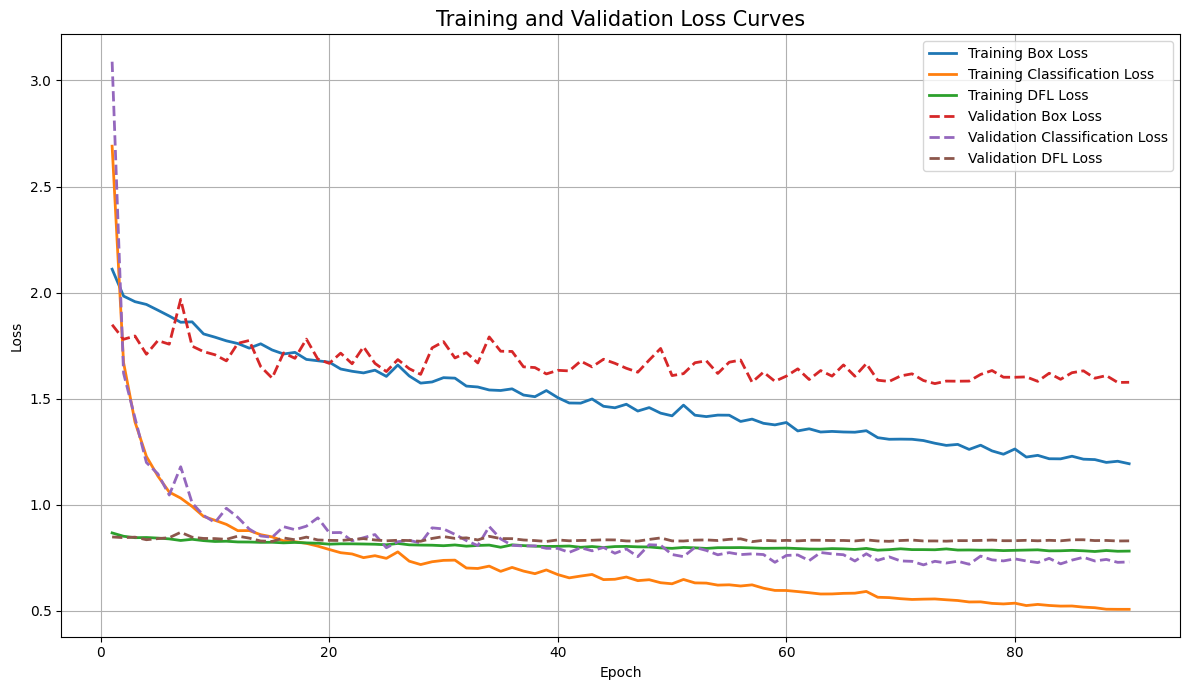

In [ ]:
# ============================================================
# Training and Validation Loss Curves
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Training Losses
plt.plot(results['epoch'], results['train/box_loss'],
         label='Training Box Loss', linewidth=2)

plt.plot(results['epoch'], results['train/cls_loss'],
         label='Training Classification Loss', linewidth=2)

plt.plot(results['epoch'], results['train/dfl_loss'],
         label='Training DFL Loss', linewidth=2)

# Validation Losses
plt.plot(results['epoch'], results['val/box_loss'],
         '--', label='Validation Box Loss', linewidth=2)

plt.plot(results['epoch'], results['val/cls_loss'],
         '--', label='Validation Classification Loss', linewidth=2)

plt.plot(results['epoch'], results['val/dfl_loss'],
         '--', label='Validation DFL Loss', linewidth=2)

plt.title("Training and Validation Loss Curves", fontsize=15)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

# Validation Performance Curves

The validation performance curves show the detection performance of the YOLOv11 model during training.

The evaluation includes:

- Precision
- Recall
- mAP@50
- mAP@50-95

These metrics provide a comprehensive assessment of the model's detection accuracy and localization performance on unseen validation data.

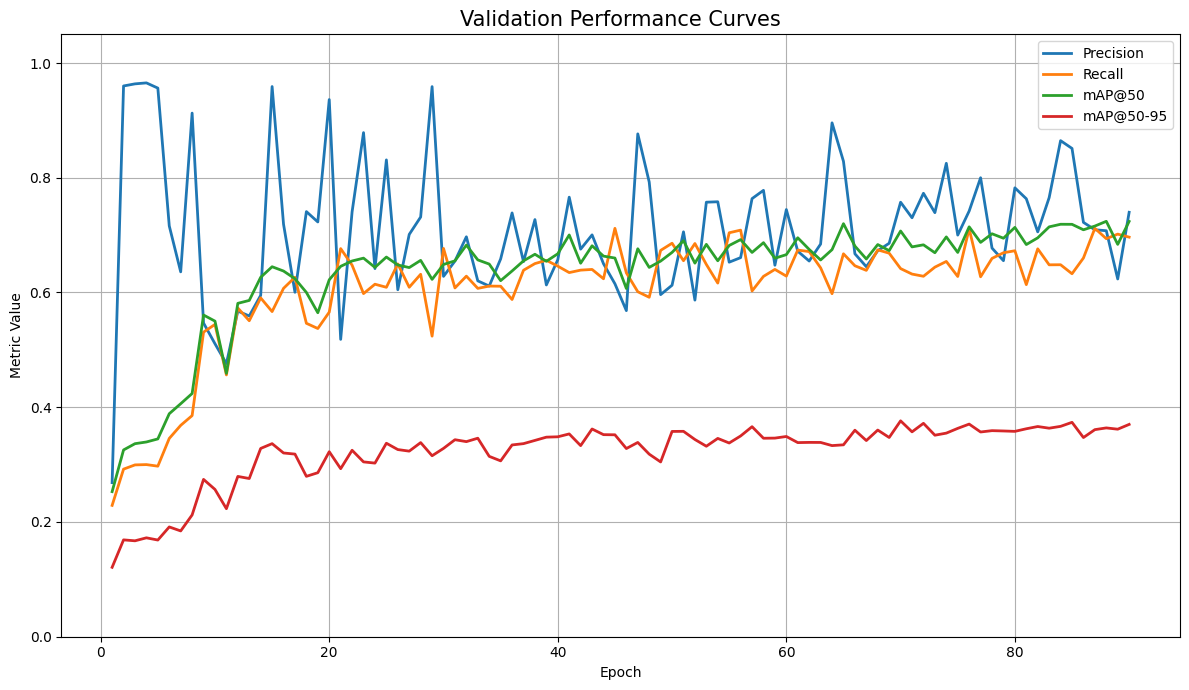

In [ ]:
# ============================================================
# Validation Performance Curves
# ============================================================

plt.figure(figsize=(12,7))

plt.plot(results['epoch'],
         results['metrics/precision(B)'],
         label='Precision',
         linewidth=2)

plt.plot(results['epoch'],
         results['metrics/recall(B)'],
         label='Recall',
         linewidth=2)

plt.plot(results['epoch'],
         results['metrics/mAP50(B)'],
         label='mAP@50',
         linewidth=2)

plt.plot(results['epoch'],
         results['metrics/mAP50-95(B)'],
         label='mAP@50-95',
         linewidth=2)

plt.title("Validation Performance Curves", fontsize=15)

plt.xlabel("Epoch")

plt.ylabel("Metric Value")

plt.ylim(0,1.05)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

# Learning Rate Schedule

The learning rate schedule illustrates how the optimizer adjusts the learning rate throughout the training process.

A gradually decreasing learning rate improves training stability and enables the model to converge more effectively toward an optimal solution.

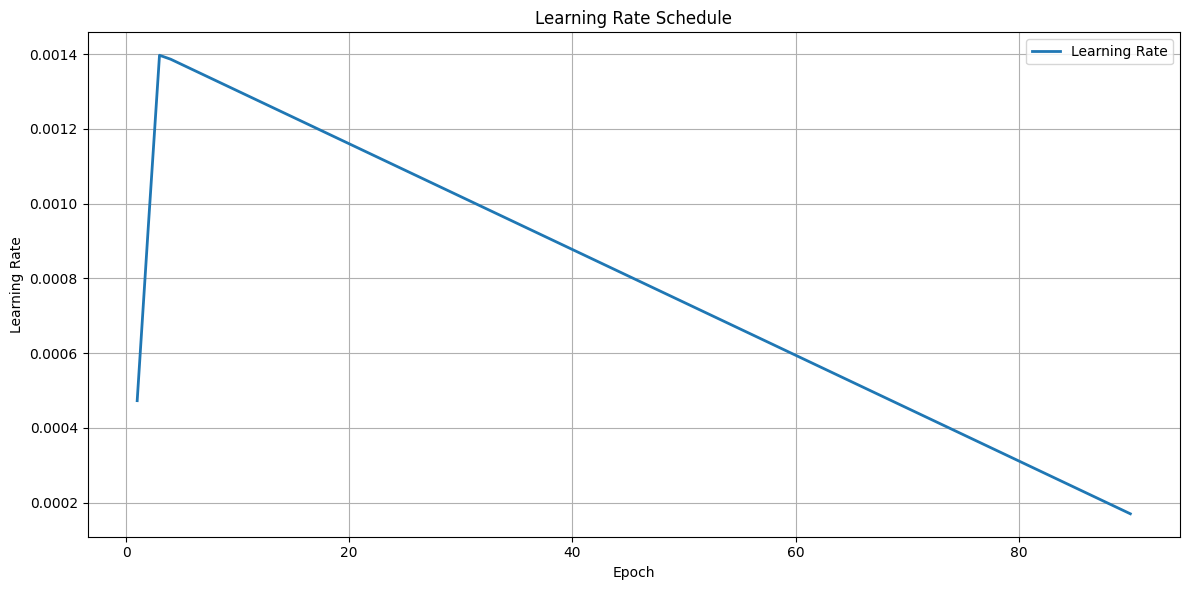